### Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# install local geoopt first: !pip install -e data/geoopt
import geoopt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import spearmanr
import matplotlib.patheffects as PathEffects

import _utils
from _utils import set_all_seeds, set_plt_layout
from _utils import calculate_reconstruction_metrics_hmtDNA, calculate_correlation_metrics_hmtDNA
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

_utils.reset_plt_layout()
set_all_seeds(0); set_plt_layout()

/tmp/ipykernel_926653/3860021947.py:10: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
df = pd.read_pickle("data/hmtDNA/rcrs.pkl", compression='gzip')
df

,SampleID,Haplogroup,Rank,Quality,Range,Not_Found_Polys,Found_Polys,Remaining_Polys,AAC_In_Remainings,Input_Sample,main_geo_loc,sub_geo_loc,latitude,longitude,distance_to_sudan
0,AB055387.1,B5b1a2,1,0.9477,1-16569,960.1C 14766T,73G 103A 199C 204C 263G 709A 750G 1438G 1598A ...,311d (globalPrivateMutation) 523d (hotspot) 52...,NaN,"[73G, 103A, 199C, 204C, 263G, 311d, 523d, 524d...",NaN,NaN,NaN,NaN,NaN
1,AB626609.1,X2e2b,1,0.9616,1-16569,NaN,73G 153G 195C 225A! 263G 750G 1438G 1719A 2706...,309.1C (hotspot) 315.1C (hotspot) 524.1AC (hot...,NaN,"[73G, 153G, 195C, 263G, 309.1C, 315.1C, 524.1A...",NaN,NaN,NaN,NaN,NaN
2,AB626610.1,H3u1,1,0.9652,1-16569,NaN,263G 750G 1438G 4769G 5899.XC 6776C 8860G 9966...,315.1C (hotspot) 3107d (hotspot) 13260C (local...,NaN,"[263G, 315.1C, 750G, 1438G, 3107d, 4769G, 5899...",NaN,NaN,NaN,NaN,NaN
3,AF346963.1,S1,1,0.8481,1-16569,NaN,73G 263G 750G 1438G 2706G 4769G 7028T 8404C 88...,150T (localPrivateMutation) 152C (localPrivate...,12358G [T8A| Codon 1 | ND5 ] 13594G [S420G| Co...,"[73G, 150T, 152C, 252C, 263G, 315.1C, 709A, 75...",Australia,NaN,-24.776109,134.755000,11927.501388
4,AF346964.1,S2,1,0.8058,1-16569,NaN,73G 263G 750G 1438G 2380T 2706G 3438A 4769G 61...,309.1C (hotspot) 315.1C (hotspot) 471C (localP...,13135A [A267T| Codon 1 | ND5 ] 13708A [A458T| ...,"[73G, 263G, 309.1C, 315.1C, 471C, 524.1ACAC, 7...",Australia,NaN,-24.776109,134.755000,11927.501388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63773,PQ468427.1,HV6a,1,1.0000,1-16569,NaN,263G 750G 1438G 2706G 3507T 4769G 6755A 7028T ...,309.1C (hotspot) 315.1C (hotspot) 3107d (hotspot),NaN,"[263G, 309.1C, 315.1C, 750G, 1438G, 2706G, 310...",Poland,NaN,52.215933,19.134422,4251.500278
63774,PQ468428.1,H7a1,1,0.9302,1-16569,NaN,263G 750G 1438G 1719A 4769G 4793G 8860G 15326G...,315.1C (hotspot) 1243C (localPrivateMutation) ...,NaN,"[263G, 315.1C, 750G, 1243C, 1438G, 1719A, 3107...",Poland,NaN,52.215933,19.134422,4251.500278
63775,PQ468429.1,H1c+152,1,0.8940,1-16569,NaN,152C 263G 477C 750G 1438G 3010A 4769G 8860G 15...,146C (localPrivateMutation) 315.1C (hotspot) 3...,NaN,"[146C, 152C, 263G, 315.1C, 326G, 477C, 750G, 1...",Poland,NaN,52.215933,19.134422,4251.500278
63776,V00662.1,M31a2*,1,0.5302,1-16569,73G 150T 195C 263G 489C 750G 868T 1438G 2156.1...,11335T 14766T 16093C!,3107C (globalPrivateMutation) 3423G (globalPri...,9559G [P118R| Codon 2 | COX3 ] 11447C [V230L| ...,"[3107C, 3423G, 4985G, 9559G, 11335T, 11447C, 1...",NaN,NaN,NaN,NaN,NaN


In [4]:
thr = 0.9
print(set(df[df['Quality'] < thr]["Haplogroup"]) - set(df[df['Quality'] >= thr]["Haplogroup"]))

df = df[df['Quality'] >= thr]
df.shape

{'M35', 'L0f1', 'R8a', 'K2c', 'L3h1b1', 'L3h1b', 'X2m', 'M42', "L2'3'4'5'6", 'H2a4', 'B4c', 'M37+152', "L0d2a'b'd", 'M17', 'L4b2a', 'M60', 'M42b2', 'M2', 'U6a7b', 'U6a', "U5a'b", 'P9a', 'B5a', 'H2a2a1', "R11'B6", 'A', 'P1d2', 'HV12a', 'L3h1a2', 'M22b', 'B4d3', 'M49', "M80'D", 'L1c3', 'B5a2a2b2', 'L3f', 'B5a2', 'M8', 'J1b1a', "U6a'b'd", 'M21b1a', 'R30a1*', 'T2+150', "L2a1'2'3'4", 'R5a', 'L3d1a1', 'D4g2a', 'M68', 'H3ak', 'P+16176', 'L4b', 'M4"67', 'H5v', 'F1+16189', 'M36', 'M46', 'F1c1', 'HV2', 'U2b', 'M33+16362', 'R8', 'F3a', 'H26b', 'L3e2a1', 'R30*', 'HV20', 'P', 'HV14', "M24'41", 'P1+152', 'P3b1', "L1c1'2'4'5'6", 'M66', 'R6+16129', "M9a'b", 'H2a2a2', 'P3b', 'M5b2b1', 'A11+16234', 'N10', "M34'57", "L3c'd", "M1'20'51", 'X2e1', 'M21b1', "U2c'd", 'S1', 'U8b1a2+16311', 'U1a', 'M52a', 'L4b1', 'G2a1f', 'HV5', 'G', 'M50', 'L4a', 'N5', 'R6+16129*', 'P4b', 'M17c1', 'K1a7', 'R30a', 'L2a5', 'B6', 'I1b*1', 'N11a', 'R6a2*', 'K1b1b', 'R22', "M32'56", 'M43a', 'U6a2', 'R30b', 'H5a1c2', 'H54', 'H41', '

(57385, 15)

In [5]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
one_hot = pd.DataFrame(mlb.fit_transform(df['Input_Sample'].values),
                       columns=mlb.classes_,
                       index=df.index)


# Calculate the frequency of each mutation
mutation_counts = one_hot.sum(axis=0)
total_samples = one_hot.shape[0]
mutation_frequencies = mutation_counts / total_samples

# Display mutation frequencies
print("\nMutation Frequencies:")
print(mutation_frequencies.head())

frequency_threshold = 0.0005
filtered_mutations = mutation_frequencies[mutation_frequencies >= frequency_threshold].index
one_hot_filtered = one_hot[filtered_mutations]
# (61665, 6298)

# Display the filtered one-hot encoded DataFrame
print(f"\nFiltered One-Hot Encoded DataFrame (Mutations with ≥ {frequency_threshold*100}% Frequency):")
print(one_hot_filtered.shape)



Mutation Frequencies:
10000A    0.000017
10000N    0.000802
10001N    0.000802
10002N    0.000732
10003C    0.000139
dtype: float64

Filtered One-Hot Encoded DataFrame (Mutations with ≥ 0.05% Frequency):
(57385, 5366)


In [6]:
df['n_mutations'] = df['Input_Sample'].apply(len)
df['n_kept_mutations'] = one_hot_filtered.sum(axis=1)
df['kept_ratio'] = df['n_kept_mutations'] / df['n_mutations'] 

print(one_hot_filtered.shape)
df[['n_mutations', 'n_kept_mutations']].describe()

# optionally only keep samples where ratio is above 0.5
# df = df[df['kept_ratio'] > 0.9]

/tmp/ipykernel_926653/219720428.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['n_mutations'] = df['Input_Sample'].apply(len)


(57385, 5366)


/tmp/ipykernel_926653/219720428.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['n_kept_mutations'] = one_hot_filtered.sum(axis=1)
/tmp/ipykernel_926653/219720428.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kept_ratio'] = df['n_kept_mutations'] / df['n_mutations']


,n_mutations,n_kept_mutations
count,57385.000000,57385.000000
mean,42.082478,38.531184
std,73.136099,35.100911
min,1.000000,1.000000
25%,30.000000,30.000000
50%,38.000000,37.000000
75%,44.000000,43.000000
max,4422.000000,1437.000000


In [ ]:
import pandas as pd
import xml.etree.ElementTree as ET

tree = ET.parse('data/hmtDNA/trees/phylotree-fu-rcrs/1.2/tree.xml') # adjusted tree path
root = tree.getroot()

haplogroup_levels = {}

def traverse(node, level):
    haplogroup_name = node.get('name')
    if haplogroup_name:
        haplogroup_levels[haplogroup_name] = level
    for child in node.findall('haplogroup'):
        traverse(child, level + 1)

traverse(root, 0)
# haplogroup_levels.pop('mtMRCA', None)
haplogroup_levels = {k: v - 1 for k, v in haplogroup_levels.items()}

df['level'] = df['Haplogroup'].map(haplogroup_levels)
assert df['level'].isna().sum() == 0
df['level'] = df['level'].astype(int)

print(haplogroup_levels, df['level'].value_counts())


{'H2a2a1': 0, 'H2a2a1a': 1, 'H2a2a1b': 1, 'H2a2a1c': 1, 'H2a2a1d': 1, 'H2a2a1e': 1, 'H2a2a1f': 1, 'H2a2a1g': 1, 'H2a2a1h': 1, 'H2a2a2': 1, 'H2a2a': 1, 'H2a2': 2, 'H2a2+(16235)': 3, 'H2a2b': 4, 'H2a2b1': 5, 'H2a2b1a': 6, 'H2a2b1a1': 7, 'H2a2b2': 5, 'H2a2b3': 5, 'H2a2b4': 5, 'H2a2b5': 5, 'H2a2b5a': 6, 'H2a': 3, 'H2a1': 4, 'H2a1*': 5, 'H2a1a': 5, 'H2a1a1': 6, 'H2a1a2': 6, 'H2a1b': 5, 'H2a1b1': 6, 'H2a1b2': 6, 'H2a1c': 5, 'H2a1d': 5, 'H2a1e': 5, 'H2a1e1': 6, 'H2a1e1a': 7, 'H2a1e1a1': 8, 'H2a1e1b': 7, 'H2a1f': 5, 'H2a1f1': 6, 'H2a1f2': 6, 'H2a1g': 5, 'H2a1i': 5, 'H2a1j': 5, 'H2a1k': 5, 'H2a1m': 5, 'H2a1+146': 5, 'H2a1n': 6, 'H2a3': 4, 'H2a3a': 5, 'H2a3a1': 6, 'H2a3b': 5, 'H2a4': 4, 'H2a5': 4, 'H2a5a': 5, 'H2a5a1': 6, 'H2a5a1a': 7, 'H2a5a1b': 7, 'H2a5b': 5, 'H2a5b1': 6, 'H2a5b2': 6, 'H2': 4, 'H2a*': 5, 'H2+152+16311': 5, 'H2b': 6, 'H2c': 6, 'H2c1': 7, 'H': 5, 'H1': 6, 'H1*1': 7, 'H1*2': 7, 'H1*3': 7, 'H1a': 7, 'H1a1': 8, 'H1a1a': 9, 'H1a1a1': 10, 'H1a1b': 9, 'H1a1c': 9, 'H1a2': 8, 'H1a3': 8,

/tmp/ipykernel_926653/3827611941.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['level'] = df['Haplogroup'].map(haplogroup_levels)
/tmp/ipykernel_926653/3827611941.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['level'] = df['level'].astype(int)


In [8]:
class Nodes(torch.utils.data.Dataset):
    def __init__(self, dataset, subset=None, level=None, haplogroup=None, obs=None):
        super(Nodes, self).__init__()
        self.data = dataset[subset] if subset is not None else dataset
        if level is not None: self.level = level[subset] if subset is not None else level
        if haplogroup is not None: self.haplogroup = haplogroup[subset] if subset is not None else haplogroup
        if obs is not None: self.obs = obs.iloc[subset] if subset is not None else obs

        self.data = torch.tensor(self.data, dtype=torch.float64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return index, self.data[index], index

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

data = torch.tensor(one_hot_filtered.loc[df.index.tolist()].values, dtype=torch.float64)

In [9]:
set_all_seeds(0)

# Split data into train, validation and test sets (82/9/9)
indices = np.arange(len(data))
np.random.shuffle(indices)

train_size = int(0.82 * len(indices))
val_size = int(0.09 * len(indices))
test_size = len(indices) - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_data = Nodes(data, train_indices, level=df['level'].values, haplogroup=df['Haplogroup'].values, obs=df)
val_data = Nodes(data, val_indices, level=df['level'].values, haplogroup=df['Haplogroup'].values, obs=df)
test_data = Nodes(data, test_indices, level=df['level'].values, haplogroup=df['Haplogroup'].values, obs=df)

batch_size = 2048
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


/tmp/ipykernel_926653/2894625206.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(self.data, dtype=torch.float64)


### Model definition

In [10]:
# ---------------------------------
# - Riemannian generative decoder - 
# ---------------------------------

class RGD(nn.Module):
    def __init__(self, dim_list, manifold=geoopt.manifolds.Euclidean(), output_activation=None):
        super(RGD, self).__init__()
        self.dim_list = dim_list 
        self.manifold = manifold 
        self.origin = self.manifold.origin(dim_list[0], seed=None, device=device)
        
        # fc decoder stack with swish activations 
        layers = []
        for i in range(len(dim_list) - 1):
            layers.append(nn.Linear(dim_list[i], dim_list[i + 1]))
            if i != len(dim_list) - 2: # only activations for hidden layers
                layers.append(nn.SiLU())
                
        if output_activation is not None:
            layers.append(output_activation)

        self.decoder = nn.Sequential(*layers)

    def forward(self, z):
        return self.decoder(z)

    def init_samples(self, n):
        # manifold-projected points with small noise opposite origin 
        z = 1e-3 * torch.randn(n, self.dim_list[0], device=device) - self.origin 
        z = self.manifold.projx(z)
        return geoopt.ManifoldParameter(z, manifold=self.manifold, requires_grad=True)
    
from _train import train_rgd
torch.set_default_dtype(torch.float64)  # Set default tensor type

In [11]:
# define parameters 
device = "cuda:0"
dim_list = [3, 16, 32, 64, 128, 256, train_data.data.shape[1]]

c = 5; std = 0.5
manifold = geoopt.manifolds.Lorentz(k=c)
# manifold = geoopt.manifolds.Euclidean(1); use_prior = True

# initialize and train model
model = RGD(dim_list, manifold)
model.z = model.init_samples(len(train_data))
model.z_val = model.init_samples(len(val_data))
train_rgd(model, F.binary_cross_entropy_with_logits, train_loader, val_loader, [1e-1, 2e-3], betas=(0.9, 0.995), 
    n_epochs=1000, device=device, patience=85, start_saving=150, wd=1e-3, noise_std=std, use_prior=False)

# find test-time representations 
loss_fn = lambda x, y: F.binary_cross_entropy_with_logits(x, y, reduction='none')
ztest = _utils.get_representations(model, test_loader, loss_fn, n_start_points_per_sample=15, n_epochs=600, lr=8e-2, betas=(0.5, 0.7), wd=0, device=device)
model.z_test = ztest

Epoch   0  T loss: 1877.1116  V loss: 211.9338  T Recon: 1877.1116  V Recon: 211.9338


Epoch  10  T loss: 123.0310  V loss: 125.0048  T Recon: 123.0310  V Recon: 125.0048


Epoch  20  T loss: 116.1073  V loss: 117.5639  T Recon: 116.1073  V Recon: 117.5639


Epoch  30  T loss: 113.3332  V loss: 114.7187  T Recon: 113.3332  V Recon: 114.7187


Epoch  40  T loss: 112.7791  V loss: 113.9623  T Recon: 112.7791  V Recon: 113.9623


...


Optimizing representations: 100%|████████████████████████████▊| 597/600 [01:08<00:00,  8.16it/s]


Optimizing representations: 100%|████████████████████████████▉| 598/600 [01:08<00:00,  8.43it/s]


Optimizing representations: 100%|████████████████████████████▉| 599/600 [01:09<00:00,  8.64it/s]


Optimizing representations: 100%|█████████████████████████████| 600/600 [01:09<00:00,  8.80it/s]


Optimizing representations: 100%|█████████████████████████████| 600/600 [01:09<00:00,  8.67it/s]

### Evaluation

In [12]:
# Compute results 
pearson, spearman = calculate_correlation_metrics_hmtDNA(model.z, manifold, train_data)
test_pearson, test_spearman = calculate_correlation_metrics_hmtDNA(model.z_test, manifold, test_data)
train_bce, train_f1 = calculate_reconstruction_metrics_hmtDNA(model, model.z, train_data)
test_bce, test_f1 = calculate_reconstruction_metrics_hmtDNA(model, model.z_test, test_data)
print(f"Train: Pearson={round(pearson, 3)}, Spearman={round(spearman, 3)}, BCE={round(train_bce, 3)}, F1={round(train_f1, 3)}")
print(f" Test: Pearson={round(test_pearson, 3)}, Spearman={round(test_spearman, 3)}, BCE={round(test_bce, 3)}, F1={round(test_f1, 3)}")

Manifold distance progress: 100/5000
Manifold distance progress: 200/5000
Manifold distance progress: 300/5000
Manifold distance progress: 400/5000
Manifold distance progress: 500/5000
Manifold distance progress: 600/5000
Manifold distance progress: 700/5000
Manifold distance progress: 800/5000
Manifold distance progress: 900/5000
Manifold distance progress: 1000/5000
Manifold distance progress: 1100/5000
Manifold distance progress: 1200/5000
Manifold distance progress: 1300/5000
Manifold distance progress: 1400/5000
Manifold distance progress: 1500/5000
Manifold distance progress: 1600/5000
Manifold distance progress: 1700/5000
Manifold distance progress: 1800/5000
Manifold distance progress: 1900/5000
Manifold distance progress: 2000/5000
Manifold distance progress: 2100/5000
Manifold distance progress: 2200/5000
Manifold distance progress: 2300/5000
Manifold distance progress: 2400/5000


Manifold distance progress: 2600/5000
Manifold distance progress: 2700/5000
Manifold distance progress: 2800/5000
Manifold distance progress: 2900/5000
Manifold distance progress: 3000/5000
Manifold distance progress: 3100/5000
Manifold distance progress: 3200/5000
Manifold distance progress: 3300/5000
Manifold distance progress: 3400/5000
Manifold distance progress: 3500/5000
Manifold distance progress: 3600/5000
Manifold distance progress: 3700/5000
Manifold distance progress: 3800/5000
Manifold distance progress: 3900/5000
Manifold distance progress: 4000/5000
Manifold distance progress: 4100/5000
Manifold distance progress: 4200/5000
Manifold distance progress: 4300/5000
Manifold distance progress: 4400/5000
Manifold distance progress: 4500/5000
Manifold distance progress: 4600/5000
Manifold distance progress: 4700/5000
Manifold distance progress: 4800/5000
Manifold distance progress: 4900/5000


Manifold distance progress: 100/5000
Manifold distance progress: 200/5000
Manifold distance progress: 300/5000
Manifold distance progress: 400/5000
Manifold distance progress: 500/5000
Manifold distance progress: 600/5000
Manifold distance progress: 700/5000
Manifold distance progress: 800/5000
Manifold distance progress: 900/5000
Manifold distance progress: 1000/5000
Manifold distance progress: 1100/5000
Manifold distance progress: 1200/5000
Manifold distance progress: 1300/5000
Manifold distance progress: 1400/5000
Manifold distance progress: 1500/5000
Manifold distance progress: 1600/5000
Manifold distance progress: 1700/5000
Manifold distance progress: 1800/5000
Manifold distance progress: 1900/5000
Manifold distance progress: 2000/5000
Manifold distance progress: 2100/5000
Manifold distance progress: 2200/5000
Manifold distance progress: 2300/5000
Manifold distance progress: 2400/5000


Manifold distance progress: 2600/5000
Manifold distance progress: 2700/5000
Manifold distance progress: 2800/5000
Manifold distance progress: 2900/5000
Manifold distance progress: 3000/5000
Manifold distance progress: 3100/5000
Manifold distance progress: 3200/5000
Manifold distance progress: 3300/5000
Manifold distance progress: 3400/5000
Manifold distance progress: 3500/5000
Manifold distance progress: 3600/5000
Manifold distance progress: 3700/5000
Manifold distance progress: 3800/5000
Manifold distance progress: 3900/5000
Manifold distance progress: 4000/5000
Manifold distance progress: 4100/5000
Manifold distance progress: 4200/5000
Manifold distance progress: 4300/5000
Manifold distance progress: 4400/5000
Manifold distance progress: 4500/5000
Manifold distance progress: 4600/5000
Manifold distance progress: 4700/5000
Manifold distance progress: 4800/5000
Manifold distance progress: 4900/5000


Train: Pearson=0.283, Spearman=0.501, BCE=0.01, F1=0.787
 Test: Pearson=0.17, Spearman=0.33, BCE=0.009, F1=0.812


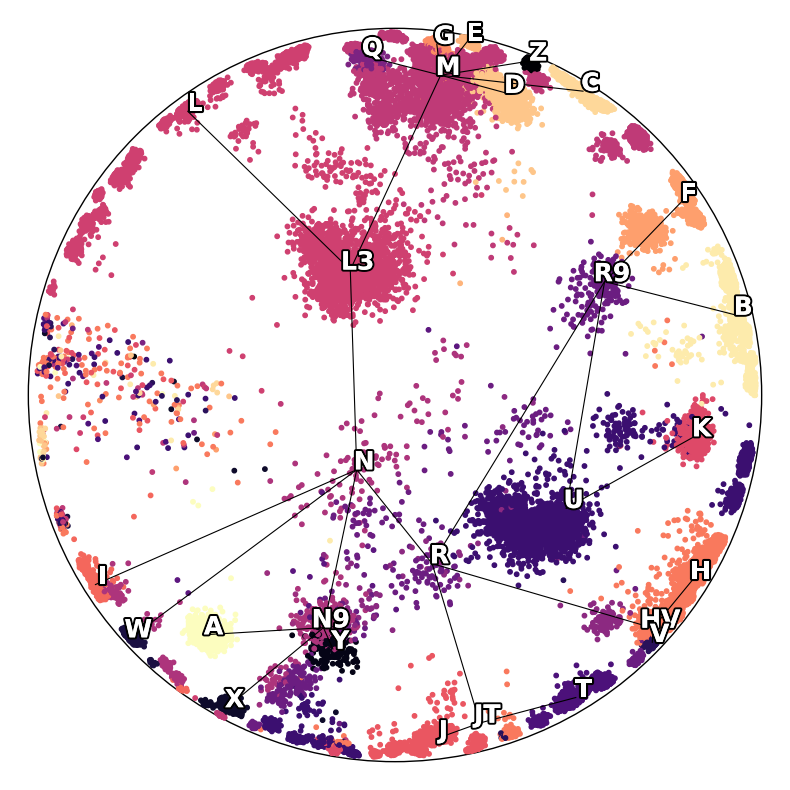

In [13]:
disk_radius = 1

def lorentz_to_poincare(z, k=c):
    return z[:, 1:] / (z[:, :1])

kept = (train_data.obs["n_kept_mutations"] / train_data.obs["n_mutations"] >= 0.5).values
z = model.z[kept]
obs = train_data.obs[kept]
z_p = lorentz_to_poincare(z)
z_p = z_p.data.cpu().numpy()

two_letter = obs.Haplogroup.str[:2]
cats2 = two_letter.astype('category')
codes2 = cats2.cat.codes.values
labels2 = cats2.cat.categories

one_letter = obs.Haplogroup.str[:1]
cats1 = one_letter.astype('category')
codes1 = cats1.cat.codes.values
labels1 = cats1.cat.categories

edges = [
    ('L','L3'),
    ('L3','M'),('L3','N'),
    ('N','R'),
    ('M','E'),('M','D'),('M','C'),('M','Z'),('M','G'),('M', 'Q'),
    ('R','HV'),('R','JT'),
    ('R', 'R9'), ('R9', 'U'), ('U', 'K'), ('R9', 'B'), ('R9', 'F'),
    ('N','W'),('N','I'), ('N', 'N9'),
    ('N9','Y'),('N9','A'),('N9','X'),
    ('HV','H'),('HV','V'),
    ('JT','J'),('JT','T'),
]

nodes = {n for e in edges for n in e}
medians = {}
for lbl in nodes:
    if lbl == 'L':
        mask = obs.Haplogroup.str.startswith('L') & ~obs.Haplogroup.str.startswith('L3')
    elif lbl == 'N':
        mask = obs.Haplogroup.str.startswith('N2') 
    elif lbl == 'L3':
        mask = obs.Haplogroup.str.startswith('L3')
    elif lbl == 'HV':
        mask = obs.Haplogroup.str.startswith('HV') 
    elif lbl == 'JT':
        mask = obs.Haplogroup.str.startswith('J') | obs.Haplogroup.str.startswith('T')
    elif lbl == 'R':
        mask = obs.Haplogroup.str.startswith('R2') 
    elif lbl == 'R9':
        mask = obs.Haplogroup.str.startswith('R9')
    elif lbl == 'U':
        mask = obs.Haplogroup.str.startswith('U')
    elif lbl == 'N9':
        mask = obs.Haplogroup.str.startswith('N9')
    else:
        mask = obs.Haplogroup.str[:1] == lbl
    if mask.any():
        medians[lbl] = (
            np.median(z_p[mask,0]),
            np.median(z_p[mask,1])
        )

fig, ax = plt.subplots(figsize=(8,8))
ax.add_artist(plt.Circle((0,0), disk_radius, fill=False, color='black'))
# ax.scatter(z_p[:,0], z_p[:,1], c=obs['level'], s=10, cmap='magma')
ax.scatter(z_p[:,0], z_p[:,1], c=codes1, s=10, cmap='magma_r')


for parent, child in edges:
    p = medians[parent]
    c = medians[child]
    ax.plot([p[0], c[0]], [p[1], c[1]], 'k-', linewidth=0.8)

for lbl, (x,y) in medians.items():
    disp = lbl if lbl in ('L3','JT','HV','N9','R9') else lbl[0]
    txt = ax.annotate(disp, (x+0.02,y+0.02), fontsize=18, fontweight='bold',
                      ha='center', va='center', color='white')
    txt.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='black'),
        PathEffects.Normal()
    ])

ax.set_xlim(-1.05,1.05)
ax.set_ylim(-1.05,1.05)
ax.set_aspect('equal', 'box')
plt.tight_layout()
# plt.savefig(f'results/pdfs/final_hmtdna_rcrs{std:.1f}std.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'results/pngs/final_hmtdna_rcrs{std:.1f}std.png', dpi=300, bbox_inches='tight')
plt.show()

### Further statistics and plotting

In [14]:
from copy import deepcopy
from geoopt import manifolds
from _utils import set_all_seeds, get_representations

N_REPS = 3

loss_fn = lambda x, y: F.binary_cross_entropy_with_logits(x, y, reduction='none')
configs = [
    ("Lorentz 0.1std 5c", manifolds.Lorentz(k=5), 0.1),
    ("Lorentz 0.5std 5c", manifolds.Lorentz(k=5), 0.5),
    ("Euclidean(2)", manifolds.Euclidean(1), 0),
]
results = {}
for name, manifold, std in configs:
    print(name)
    pearsons_train, spearmans_train, bces_train, f1s_train = [], [], [], []
    pearsons_test, spearmans_test, bces_test, f1s_test = [], [], [], []
    
    for rep in range(N_REPS):  
        set_all_seeds(rep)
        dim_list = [3, 16, 32, 64, 128, 256, train_data.data.shape[1]] 
        use_prior = False
        if name == "Euclidean(2)": 
            dim_list[0] = 2
            use_prior = True
        model = RGD(dim_list, manifold)
        model.z = model.init_samples(len(train_data))
        model.z_val = model.init_samples(len(val_data))
        train_rgd(model, F.binary_cross_entropy_with_logits, train_loader, val_loader, 
            [1e-1, 2e-3], betas=(0.9, 0.995), n_epochs=1000, device=device, beta=100, use_prior=use_prior,
            patience=85, start_saving=150, wd=1e-3, noise_std=std)

        # Train metrics
        ztrain = model.z.detach()
        p_train, s_train = calculate_correlation_metrics_hmtDNA(ztrain, manifold, train_data)
        m1_train, m2_train = calculate_reconstruction_metrics_hmtDNA(model, ztrain, train_data)
        pearsons_train.append(p_train)
        spearmans_train.append(s_train)
        bces_train.append(m1_train)
        f1s_train.append(m2_train)

        # Test metrics
        ztest = get_representations(model, test_loader, loss_fn, n_start_points_per_sample=15, n_epochs=600, lr=8e-2, betas=(0.5, 0.7), wd=0, device=device)
        model.z_test = ztest
        p_test, s_test = calculate_correlation_metrics_hmtDNA(ztest, manifold, test_data)
        m1_test, m2_test = calculate_reconstruction_metrics_hmtDNA(model, ztest, test_data)
        pearsons_test.append(p_test)
        spearmans_test.append(s_test)
        bces_test.append(m1_test)
        f1s_test.append(m2_test)

        if rep == 0:
            # save the model
            if name == "Lorentz 0.1std 5c":
                lorentz01 = deepcopy(model)
            elif name == "Euclidean(2)":
                euclidean = deepcopy(model)
        if rep == 1:
            if name == "Lorentz 0.5std 5c":
                lorentz05 = deepcopy(model)
        
    results[name] = {
        'train': {
            'pearson_mean': np.mean(pearsons_train), 'pearson_std': np.std(pearsons_train),
            'spearman_mean': np.mean(spearmans_train), 'spearman_std': np.std(spearmans_train),
            'bce_mean': np.mean(bces_train), 'bce_std': np.std(bces_train),
            'F1_mean': np.mean(f1s_train), 'F1_std': np.std(f1s_train)
        },
        'test': {
            'pearson_mean': np.mean(pearsons_test), 'pearson_std': np.std(pearsons_test),
            'spearman_mean': np.mean(spearmans_test), 'spearman_std': np.std(spearmans_test), 
            'bce_mean': np.mean(bces_test), 'bce_std': np.std(bces_test),
            'F1_mean': np.mean(f1s_test), 'F1_std': np.std(f1s_test)
        }
    }
print(results)

Lorentz 0.1std 5c


Epoch   0  T loss: 1882.1060  V loss: 209.6786  T Recon: 1882.1060  V Recon: 209.6786


Epoch  10  T loss: 118.7055  V loss: 119.0008  T Recon: 118.7055  V Recon: 119.0008


Epoch  20  T loss: 104.7104  V loss: 105.6541  T Recon: 104.7104  V Recon: 105.6541


Epoch  30  T loss: 102.1477  V loss: 103.3010  T Recon: 102.1477  V Recon: 103.3010


...


Optimizing representations: 100%|█████████████████████████████| 600/600 [01:08<00:00,  8.94it/s]


Optimizing representations: 100%|█████████████████████████████| 600/600 [01:08<00:00,  8.74it/s]

Manifold distance progress: 100/5000
Manifold distance progress: 200/5000
Manifold distance progress: 300/5000
Manifold distance progress: 400/5000
Manifold distance progress: 500/5000
Manifold distance progress: 600/5000
Manifold distance progress: 700/5000
Manifold distance progress: 800/5000
Manifold distance progress: 900/5000
Manifold distance progress: 1000/5000
Manifold distance progress: 1100/5000
Manifold distance progress: 1200/5000
Manifold distance progress: 1300/5000
Manifold distance progress: 1400/5000
Manifold distance progress: 1500/5000
Manifold distance progress: 1600/5000
Manifold distance progress: 1700/5000
Manifold distance progress: 1800/5000
Manifold distance progress: 1900/5000
Manifold distance progress: 2000/5000
Manifold distance progress: 2100/5000
Manifold distance progress: 2200/5000
Manifold distance progress: 2300/5000
Manifold distance progress: 2400/5000
Manifold distance progress: 2500/5000
Manifold distance progress: 2600/5000
Manifold distance pro

Manifold distance progress: 4100/5000
Manifold distance progress: 4200/5000
Manifold distance progress: 4300/5000
Manifold distance progress: 4400/5000
Manifold distance progress: 4500/5000
Manifold distance progress: 4600/5000
Manifold distance progress: 4700/5000
Manifold distance progress: 4800/5000
Manifold distance progress: 4900/5000


{'Lorentz 0.1std 5c': {'train': {'pearson_mean': 0.17525515754372026, 'pearson_std': 0.01758976036382396, 'spearman_mean': 0.16570780926398757, 'spearman_std': 0.049007823025154676, 'bce_mean': 0.0050624686932980445, 'bce_std': 4.455507468530585e-05, 'F1_mean': 0.8813391872454653, 'F1_std': 0.001500885407987302}, 'test': {'pearson_mean': -0.0005372674589666782, 'pearson_std': 0.07580714834092817, 'spearman_mean': -0.03883270552297935, 'spearman_std': 0.1285226756379727, 'bce_mean': 0.021908443167611116, 'bce_std': 0.0030530446282482603, 'F1_mean': 0.7396497574410296, 'F1_std': 0.006681390111507054}}, 'Lorentz 0.5std 5c': {'train': {'pearson_mean': 0.27632979981131583, 'pearson_std': 0.013533568022966798, 'spearman_mean': 0.4570464671630669, 'spearman_std': 0.035386264562878585, 'bce_mean': 0.00982303398981862, 'bce_std': 0.00020904815850601193, 'F1_mean': 0.7786390820919459, 'F1_std': 0.0067416163705861}, 'test': {'pearson_mean': 0.1457648027706833, 'pearson_std': 0.008423582329331854,

In [15]:
# Build a DataFrame `df` with results
idx = []
data = {}
for name, vals in results.items():
    idx.append(name)
    for split, split_name in [('train', 'Train'), ('test', 'Test')]:
        for metric, metric_name in [
            ('pearson', 'Pearson'),
            ('spearman', 'Spearman'),
            ('bce', 'BCE'),
            ('F1', 'F1')
        ]:
            m = vals[split][f'{metric}_mean']
            s = vals[split][f'{metric}_std']
            # entry = f"{m:.2f}\\raisebox{{0.ex}}{{\\scriptsize $\\pm${s:.2f}}}"
            entry = f"{m:.2f}{{\\scriptsize $\\pm${s:.2f}}}"
            data.setdefault((split_name, metric_name), []).append(entry)

df = pd.DataFrame(data, index=idx)
df.index.name = 'Manifold'
cols = [(g, m) for g in ['Train', 'Test'] for m in ['Pearson', 'Spearman', 'BCE', 'F1']]
df = df[cols]

name_map = {
    "Lorentz 0.1std 5c": r"rCRS $\mathbb{H}^2$ {\scriptsize($\sigma=0.1$)}",
    "Lorentz 0.5std 5c": r"rCRS $\mathbb{H}^2$ {\scriptsize($\sigma=0.5$)}",
    "Euclidean(2)":      r"rCRS $\mathbb{R}^2$ {\scriptsize($\sigma=0.0$)}",
}

# Print LaTeX table manually
print(r"\begin{table}")
print(r"\caption{\textbf{Correlation and reconstruction metrics across three runs for the hmtDNA dataset (formatted as mean $\pm$ std).}}\vspace{4px}")
print(r"\label{tab:rcrs}")
print(r"\resizebox{\textwidth}{!}{%")
print(r"\begin{tabular}{c|cccc|cccc}")
print(r"\multicolumn{1}{l}{} & \multicolumn{4}{c}{\textbf{Train}} & \multicolumn{4}{c}{\textbf{Test}} \\")
print(r"& Pearson & Spearman & BCE & F1 & Pearson & Spearman & BCE & F1 \\")
print(r"\midrule")
for name in df.index:
    label = name_map.get(name, name)
    entries = [
        df.loc[name, ('Train','Pearson')],
        df.loc[name, ('Train','Spearman')],
        df.loc[name, ('Train','BCE')],
        df.loc[name, ('Train','F1')],
        df.loc[name, ('Test','Pearson')],
        df.loc[name, ('Test','Spearman')],
        df.loc[name, ('Test','BCE')],
        df.loc[name, ('Test','F1')],
    ]
    print(f"{label} & " + " & ".join(entries) + r" \\")
print(r"\end{tabular}")
print(r"}")
print(r"\end{table}")

\begin{table}
\caption{\textbf{Correlation and reconstruction metrics across three runs for the hmtDNA dataset (formatted as mean $\pm$ std).}}\vspace{4px}
\label{tab:rcrs}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c|cccc|cccc}
\multicolumn{1}{l}{} & \multicolumn{4}{c}{\textbf{Train}} & \multicolumn{4}{c}{\textbf{Test}} \\
& Pearson & Spearman & BCE & F1 & Pearson & Spearman & BCE & F1 \\
\midrule
rCRS $\mathbb{H}^2$ {\scriptsize($\sigma=0.1$)} & 0.18{\scriptsize $\pm$0.02} & 0.17{\scriptsize $\pm$0.05} & 0.01{\scriptsize $\pm$0.00} & 0.88{\scriptsize $\pm$0.00} & -0.00{\scriptsize $\pm$0.08} & -0.04{\scriptsize $\pm$0.13} & 0.02{\scriptsize $\pm$0.00} & 0.74{\scriptsize $\pm$0.01} \\
rCRS $\mathbb{H}^2$ {\scriptsize($\sigma=0.5$)} & 0.28{\scriptsize $\pm$0.01} & 0.46{\scriptsize $\pm$0.04} & 0.01{\scriptsize $\pm$0.00} & 0.78{\scriptsize $\pm$0.01} & 0.15{\scriptsize $\pm$0.01} & 0.28{\scriptsize $\pm$0.03} & 0.01{\scriptsize $\pm$0.00} & 0.80{\scriptsize $\pm$0.01} \\
rCRS $\mathbb

In [16]:
# Define region mapping based on haplogroup first character
def map_region(haplogroup):
    if not isinstance(haplogroup, str) or len(haplogroup) == 0:
        return 'Other'
    first_char = haplogroup[0].upper()
    if first_char == 'L':
        return 'Africa'
    elif first_char in ['F', 'B', 'P', 'A', 'S', 'O', 'Y', 'N', 'M', 'Q', 'G', 'E', 'D', 'C', 'Z']:
        return 'Asia'
    elif first_char in ['H', 'V', 'U', 'K', 'J', 'T', 'R', 'W', 'X', 'I']:
        return 'Europe'
    else:
        return 'Other'

train_data.obs['Region'] = train_data.obs['Haplogroup'].apply(map_region)
train_data.obs['Region'].value_counts()
hap = train_data.obs.Haplogroup.str[:2].astype('category').cat.codes
muts = (train_data.obs["n_kept_mutations"]  / train_data.obs["n_mutations"]).values


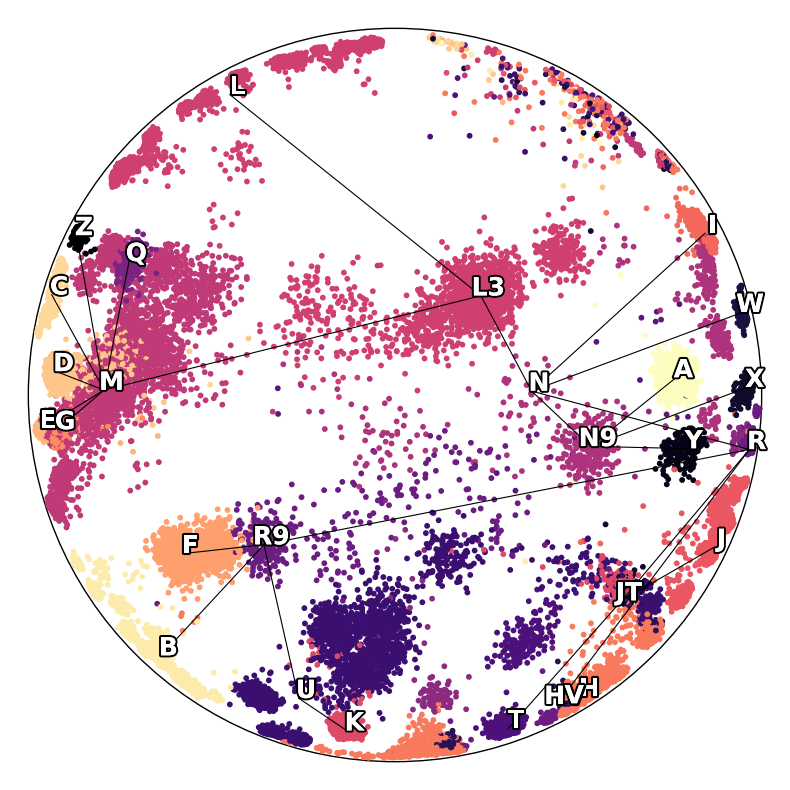

In [ ]:
# REDEFINE current_model for correct manifold.name in plotting code
current_model = lorentz05
manifold = current_model.manifold

z = current_model.z[kept]
obs = train_data.obs[kept]

z_p = lorentz_to_poincare(z) if manifold.name=='Lorentz' else z
z_p = z_p.data.cpu().numpy()

two_letter = obs.Haplogroup.str[:2]
cats2 = two_letter.astype('category')
codes2 = cats2.cat.codes.values
labels2 = cats2.cat.categories

one_letter = obs.Haplogroup.str[:1]
cats1 = one_letter.astype('category')
codes1 = cats1.cat.codes.values
labels1 = cats1.cat.categories

edges = [
    ('L','L3'),
    ('L3','M'),('L3','N'),
    ('N','R'),
    ('M','E'),('M','D'),('M','C'),('M','Z'),('M','G'),('M', 'Q'),
    ('R','HV'),('R','JT'),
    ('R', 'R9'), ('R9', 'U'), ('U', 'K'), ('R9', 'B'), ('R9', 'F'),
    ('N','W'),('N','I'), ('N', 'N9'), 
    ('N9','Y'),('N9','A'),('N9','X'),
    ('HV','H'),('HV','V'),
    ('JT','J'),('JT','T'),
]

nodes = {n for e in edges for n in e}
medians = {}
for lbl in nodes:
    if lbl == 'L':
        mask = obs.Haplogroup.str.startswith('L') & ~obs.Haplogroup.str.startswith('L3')
    elif lbl == 'N':
        mask = obs.Haplogroup.str.startswith('N2') 
    elif lbl == 'L3':
        mask = obs.Haplogroup.str.startswith('L3')
    elif lbl == 'HV':
        mask = obs.Haplogroup.str.startswith('HV') 
    elif lbl == 'JT':
        mask = obs.Haplogroup.str.startswith('J') | obs.Haplogroup.str.startswith('T')
    elif lbl == 'R':
        mask = obs.Haplogroup.str.startswith('R2')
    elif lbl == 'R9':
        mask = obs.Haplogroup.str.startswith('R9')
    elif lbl == 'U':
        mask = obs.Haplogroup.str.startswith('U')
    elif lbl == 'N9':
        mask = obs.Haplogroup.str.startswith('N9')
    else:
        mask = obs.Haplogroup.str[:1] == lbl
    if mask.any():
        medians[lbl] = (
            np.median(z_p[mask,0]),
            np.median(z_p[mask,1])
        )

fig, ax = plt.subplots(figsize=(8,8))
ax.add_artist(plt.Circle((0,0), disk_radius, fill=False, color='black'))
ax.scatter(z_p[:,0], z_p[:,1], c=codes1, s=10, cmap='magma_r')


for parent, child in edges:
    p = medians[parent]
    c = medians[child]
    ax.plot([p[0], c[0]], [p[1], c[1]], 'k-', linewidth=0.8)

for lbl, (x,y) in medians.items():
    disp = lbl if lbl in ('L3','JT','HV','N9','R9') else lbl[0]
    txt = ax.annotate(disp, (x+0.02,y+0.02), fontsize=18, fontweight='bold',
                      ha='center', va='center', color='white')
    txt.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='black'),
        PathEffects.Normal()
    ])

ax.set_xlim(-1.05,1.05)
ax.set_ylim(-1.05,1.05)
ax.set_aspect('equal', 'box')
plt.tight_layout()
# plt.savefig(f'results/pdfs/final_hmtdna_rcrs{std:.1f}std.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'results/pngs/final_hmtdna_rcrs{std:.1f}std.png', dpi=300, bbox_inches='tight')
plt.show()


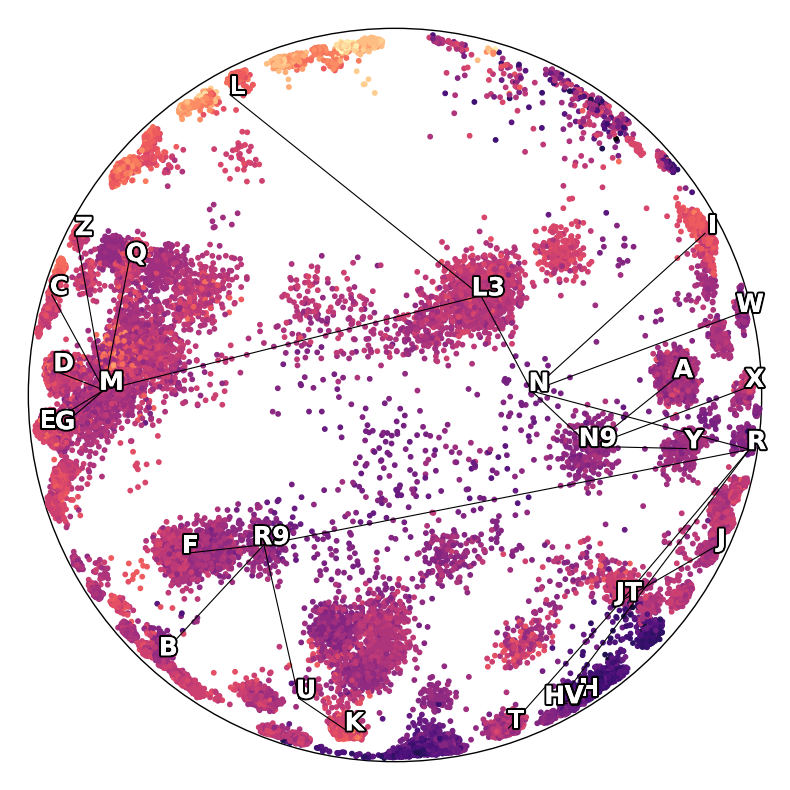

In [18]:
fig, ax = plt.subplots(figsize=(8,8))
ax.add_artist(plt.Circle((0,0), disk_radius, fill=False, color='black'))
ax.scatter(z_p[:,0], z_p[:,1], c=obs['level'], s=10, cmap='magma')

for parent, child in edges:
    p = medians[parent]
    c = medians[child]
    ax.plot([p[0], c[0]], [p[1], c[1]], 'k-', linewidth=0.8)

for lbl, (x,y) in medians.items():
    disp = lbl if lbl in ('L3','JT','HV','N9','R9') else lbl[0]
    txt = ax.annotate(disp, (x+0.02,y+0.02), fontsize=18, fontweight='bold',
                      ha='center', va='center', color='white')
    txt.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='black'),
        PathEffects.Normal()
    ])

ax.set_xlim(-1.05,1.05)
ax.set_ylim(-1.05,1.05)
ax.set_aspect('equal', 'box')
plt.tight_layout()
# plt.savefig(f'results/pdfs/final_level_hmtdna_rcrs{std:.1f}std.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'results/pngs/final_level_hmtdna_rcrs{std:.1f}std.png', dpi=300, bbox_inches='tight')
plt.show()


### Noise ablation

In [19]:
noise_levels = np.linspace(0, np.sqrt(5), 8) ** 2  # Quadratic spacing
noise_levels = np.round(noise_levels, 1)[:-2]
print("Noise levels (std):", noise_levels)


Noise levels (std): [0.  0.1 0.4 0.9 1.6 2.6]


In [ ]:
# REDEFINE these at the start of the noise ablation cell
dim_list = [3, 16, 32, 64, 128, 256, train_data.data.shape[1]] 
manifold = geoopt.manifolds.Lorentz(k=5) 
c = 5 

# storage
models = {}
metrics = []

for std in noise_levels:
    print(f"\nTraining σ = {std:.4f} …")
    set_all_seeds(0)
    # init & train
    model = RGD(dim_list, manifold)
    model.z     = model.init_samples(len(train_data))
    model.z_val = model.init_samples(len(val_data))
    train_rgd(model, F.binary_cross_entropy_with_logits, train_loader, val_loader, 
        [1e-1, 2e-3], betas=(0.9, 0.995), n_epochs=1000, device=device, beta=100, use_prior=False,
        print_loss_step=5, patience=85, start_saving=150, wd=1e-3, noise_std=std)
    models[std] = model

    # compute train‐set metrics
    zt = model.z.detach()
    _, p = calculate_correlation_metrics_hmtDNA(zt, manifold, train_data)
    _, mse = calculate_reconstruction_metrics_hmtDNA(model, zt, train_data)
    metrics.append((std, p, mse))

# # Save models
# for std, model in models.items():
#     torch.save(model.state_dict(), f'models/mtdna_rcrs_countries_std{std:.1f}.pt')
#     print(f"Saved model with std={std:.1f} at path: models/mtdna_rcrs_countries_std{std:.1f}.pt")


Training σ = 0.0000 …


Epoch   0  T loss: 1882.2839  V loss: 209.6238  T Recon: 1882.2839  V Recon: 209.6238


Epoch   5  T loss: 123.7581  V loss: 126.0132  T Recon: 123.7581  V Recon: 126.0132


Epoch  10  T loss: 117.6262  V loss: 117.3174  T Recon: 117.6262  V Recon: 117.3174


Epoch  15  T loss: 105.7866  V loss: 106.3354  T Recon: 105.7866  V Recon: 106.3354


...

Epoch 225  T loss: 172.1305  V loss: 150.1170  T Recon: 172.1305  V Recon: 150.1170


Epoch 230  T loss: 120.8254  V loss: 122.0240  T Recon: 120.8254  V Recon: 122.0240


Epoch 235  T loss: 122.3082  V loss: 122.1965  T Recon: 122.3082  V Recon: 122.1965
Early stopping
Best epoch: 150 val loss: 120.52691656119008
Manifold distance progress: 100/5000
Manifold distance progress: 200/5000
Manifold distance progress: 300/5000
Manifold distance progress: 400/5000
Manifold distance progress: 500/5000
Manifold distance progress: 600/5000
Manifold distance progress: 700/5000
Manifold distance progress: 800/5000
Manifold distance progress: 900/5000
Manifold distance progress: 1000/5000
Manifold distance progress: 1100/5000
Manifold distance progress: 1200/5000
Manifold distance progress: 1300/5000
Manifold distance progress: 1400/5000


Manifold distance progress: 1600/5000
Manifold distance progress: 1700/5000
Manifold distance progress: 1800/5000
Manifold distance progress: 1900/5000
Manifold distance progress: 2000/5000
Manifold distance progress: 2100/5000
Manifold distance progress: 2200/5000
Manifold distance progress: 2300/5000
Manifold distance progress: 2400/5000
Manifold distance progress: 2500/5000
Manifold distance progress: 2600/5000
Manifold distance progress: 2700/5000
Manifold distance progress: 2800/5000
Manifold distance progress: 2900/5000
Manifold distance progress: 3000/5000
Manifold distance progress: 3100/5000
Manifold distance progress: 3200/5000
Manifold distance progress: 3300/5000
Manifold distance progress: 3400/5000
Manifold distance progress: 3500/5000
Manifold distance progress: 3600/5000
Manifold distance progress: 3700/5000
Manifold distance progress: 3800/5000
Manifold distance progress: 3900/5000


Manifold distance progress: 4100/5000
Manifold distance progress: 4200/5000
Manifold distance progress: 4300/5000
Manifold distance progress: 4400/5000
Manifold distance progress: 4500/5000
Manifold distance progress: 4600/5000
Manifold distance progress: 4700/5000
Manifold distance progress: 4800/5000
Manifold distance progress: 4900/5000


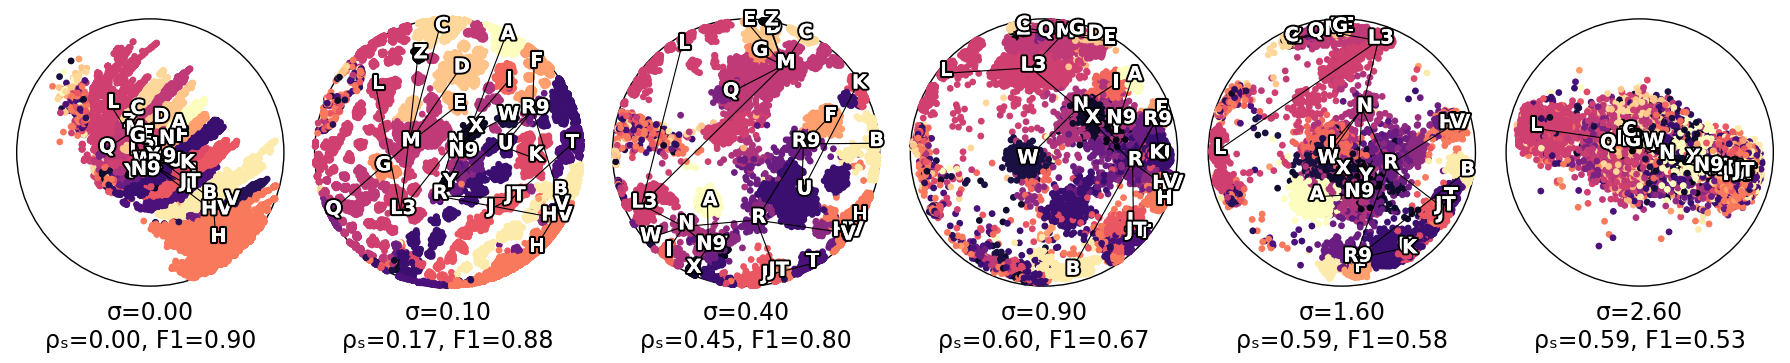

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as PathEffects

def lorentz_to_poincare(z, k=c):
    return z[:, 1:] / (z[:, :1])

subset = metrics
disk_radius = 1
kept = (train_data.obs["n_kept_mutations"] / train_data.obs["n_mutations"] >= 0.5).values

obs = train_data.obs[kept]

two_letter = obs.Haplogroup.str[:2]
cats2 = two_letter.astype('category')
codes2 = cats2.cat.codes.values
labels2 = cats2.cat.categories

one_letter = obs.Haplogroup.str[:1]
cats1 = one_letter.astype('category')
codes1 = cats1.cat.codes.values
labels1 = cats1.cat.categories

edges = [
    ('L','L3'),
    ('L3','M'),('L3','N'),
    ('N','R'),
    ('M','E'),('M','D'),('M','C'),('M','Z'),('M','G'),('M','Q'),
    ('R','HV'),('R','JT'),
    ('R','R9'), ('R9','U'), ('U','K'), ('R9','B'), ('R9','F'),
    ('N','W'),('N','I'), ('N','N9'),
    ('N9','Y'),('N9','A'),('N9','X'),
    ('HV','H'),('HV','V'),
    ('JT','J'),('JT','T'),
]

fig, axes = plt.subplots(1, len(subset), figsize=(18, 5))
plt.subplots_adjust(wspace=0.02, bottom=0.18)

for ax, (std, pearson, mse) in zip(axes, subset):
    zt = models[std].z.detach()[kept]
    zp = lorentz_to_poincare(zt)
    zp = zp.data.cpu().numpy() # Added conversion to numpy for plotting

    nodes = {n for e in edges for n in e}
    medians = {}
    for lbl in nodes:
        if lbl == 'L':
            mask = obs.Haplogroup.str.startswith('L') & ~obs.Haplogroup.str.startswith('L3')
        elif lbl == 'N':
            mask = obs.Haplogroup.str.startswith('N2')
        elif lbl == 'L3':
            mask = obs.Haplogroup.str.startswith('L3')
        elif lbl == 'HV':
            mask = obs.Haplogroup.str.startswith('HV')
        elif lbl == 'JT':
            mask = obs.Haplogroup.str.startswith('J') | obs.Haplogroup.str.startswith('T')
        elif lbl == 'R':
            mask = obs.Haplogroup.str.startswith('R2')
        elif lbl == 'R9':
            mask = obs.Haplogroup.str.startswith('R9')
        elif lbl == 'U':
            mask = obs.Haplogroup.str.startswith('U')
        elif lbl == 'N9':
            mask = obs.Haplogroup.str.startswith('N9')
        else:
            mask = obs.Haplogroup.str[:1] == lbl
        if mask.any():
            medians[lbl] = (np.median(zp[mask,0]), np.median(zp[mask,1]))

    ax.add_artist(plt.Circle((0, 0), disk_radius, edgecolor='black', fill=False))
    ax.scatter(zp[:, 0], zp[:, 1], c=codes1, s=15, alpha=1, cmap='magma_r')

    for parent, child in edges:
        p = medians[parent]
        c = medians[child]
        ax.plot([p[0], c[0]], [p[1], c[1]], 'k-', linewidth=0.8)

    for lbl, (x, y) in medians.items():
        disp = lbl if lbl in ('L3','JT','HV','N9','R9') else lbl[0]
        txt = ax.annotate(disp, (x+0.02, y+0.02), fontsize=14, fontweight='bold',
                          ha='center', va='center', color='white')
        txt.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='black'),
            PathEffects.Normal()
        ])

    if manifold.name == 'Lorentz':
        ax.set_xlim(-1.05 * disk_radius, 1.05 * disk_radius)
        ax.set_ylim(-1.05 * disk_radius, 1.05 * disk_radius)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

    ax.text(
        0.5, -0.03,
        f"σ={std:.2f}\nρₛ={pearson:.2f}, F1={mse:.2f}",
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=17
    )

plt.tight_layout()
# plt.savefig('results/pngs/app_hmtdna_ablation_spearman.png', dpi=300, bbox_inches='tight')
# plt.savefig('results/pdfs/app_hmtdna_ablation_spearman.pdf', dpi=300, bbox_inches='tight')
plt.show()
